# **Unsupervised Learning : Credit Card Customer Segmentation**

**Context**

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help

**Objective**

To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

**Data Description**

The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

**Data Dictionary**



*   Sl_No: Primary key of the records
*   Customer Key: Customer identification number


*   Average Credit Limit: Average credit limit of each customer for all credit cards
*   Total credit cards: Total number of credit cards possessed by the customer


*   Total visits bank: Total number of visits that the customer made (yearly) personally to the bank
*   Total visits online: Total number of visits or online logins made by the customer (yearly)


*   Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)










**Importing Libraries**

In [2]:
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

# to perform PCA
from sklearn.decomposition import PCA

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

**Loading data**

In [3]:
data = pd.read_excel("/content/Credit Card Customer Data.xlsx")

In [4]:
data.shape

(660, 7)



*   The dataset has 660 rows and 7 columns.



In [5]:
data.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [6]:
data.sample(n=10, random_state=1)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
547,548,38125,26000,4,5,2,4
353,354,94437,9000,5,4,1,3
499,500,65825,68000,6,4,2,2
173,174,38410,9000,2,1,5,8
241,242,81878,10000,4,5,1,3
341,342,70779,18000,4,3,2,0
647,648,79953,183000,9,0,9,2
218,219,28208,19000,3,1,5,7
120,121,16577,10000,4,2,4,6
134,135,31256,13000,4,1,5,7


**Creating copy of original data**

In [7]:
df = data.copy()

**Checking data types of column**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [9]:
df.drop(["Sl_No","Customer Key"], axis=1, inplace=True)

In [10]:
df.duplicated().sum()

np.int64(11)

In [59]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,credit_limit_log,K_means_segments
310,5000,4,5,0,1,8.517393,0
395,5000,4,5,0,1,8.517393,0
56,6000,1,0,2,5,8.699681,1
175,6000,1,0,2,5,8.699681,1
17,8000,2,0,3,4,8.987322,1
162,8000,2,0,3,4,8.987322,1
29,8000,4,0,4,7,8.987322,1
215,8000,4,0,4,7,8.987322,1
334,8000,7,4,2,0,8.987322,0
385,8000,7,4,2,0,8.987322,0




*   There are duplicate observations in the data, but we will keep it as might 2 customers has similar attributes.


In [11]:
df.isnull().sum()

,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0




*   There is no any missing value in the data.



In [12]:
df.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000




*   The average of average credit card limit is 55141.
*   The average of total credit card is 4.7.

*   The average of total visits in bank is 2.40.
*   The average of total online visit is 2.60.

*   The average of total calls made is 3.58.







# **Exploratory Data Analysis**

**Univariate Analysis**

**Average Credit Limit**

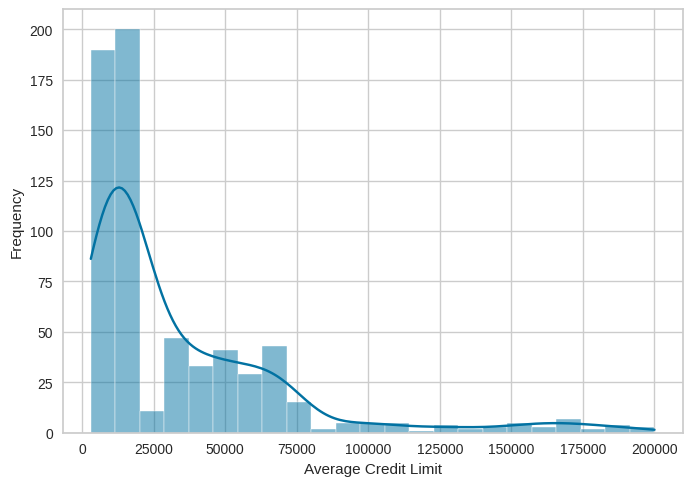

In [13]:
sns.histplot(df["Avg_Credit_Limit"], kde=True)
plt.xlabel("Average Credit Limit")
plt.ylabel("Frequency")
plt.show()



*   Most of the credit cards has limit less than 25000.


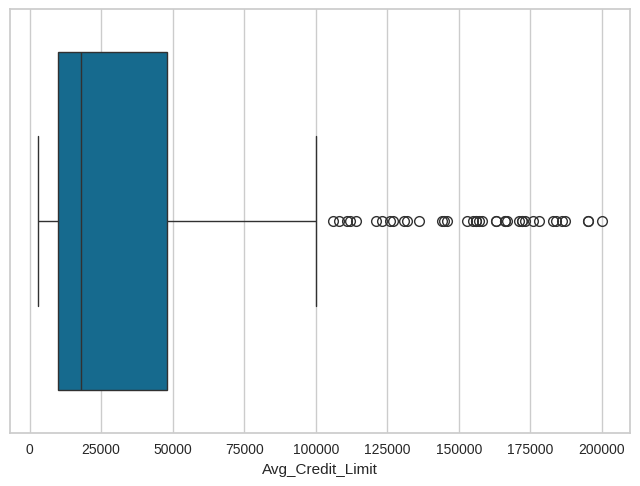

In [14]:
sns.boxplot(df,x='Avg_Credit_Limit')
plt.show()



*   The distribution is positively skewed.



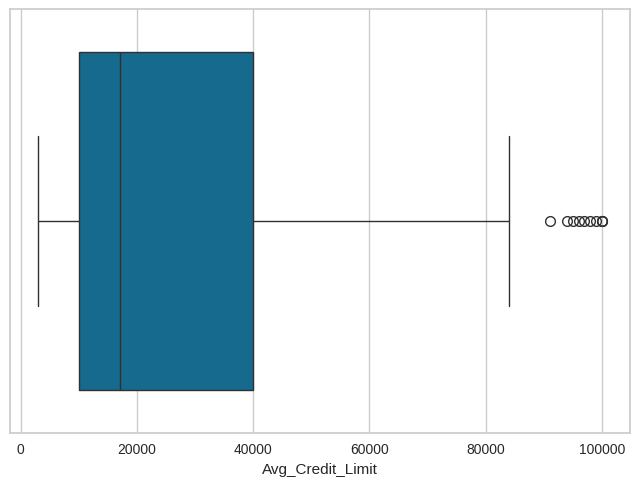

In [15]:
Q1 = data['Avg_Credit_Limit'].quantile(0.25)
Q3 = data['Avg_Credit_Limit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['Avg_Credit_Limit'] >= lower_bound) & (data['Avg_Credit_Limit'] <= upper_bound)]
sns.boxplot(data,x='Avg_Credit_Limit')
plt.show()



*   The distribution is still little positively skewed.



In [16]:
df['credit_limit_log'] = np.log1p(df['Avg_Credit_Limit'])

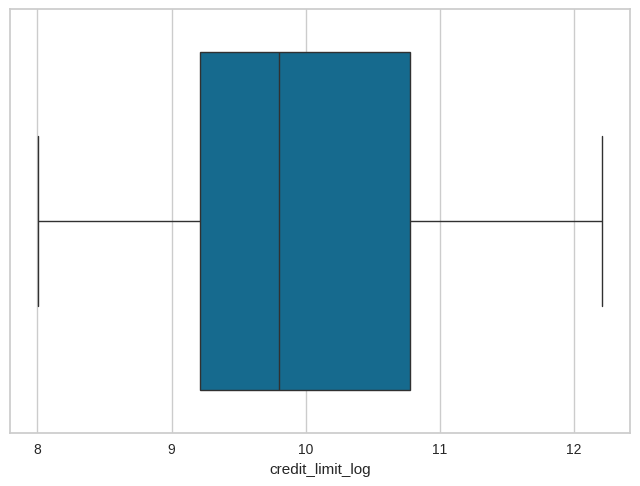

In [17]:
sns.boxplot(df,x='credit_limit_log')
plt.show()

**Total Credit Cards**

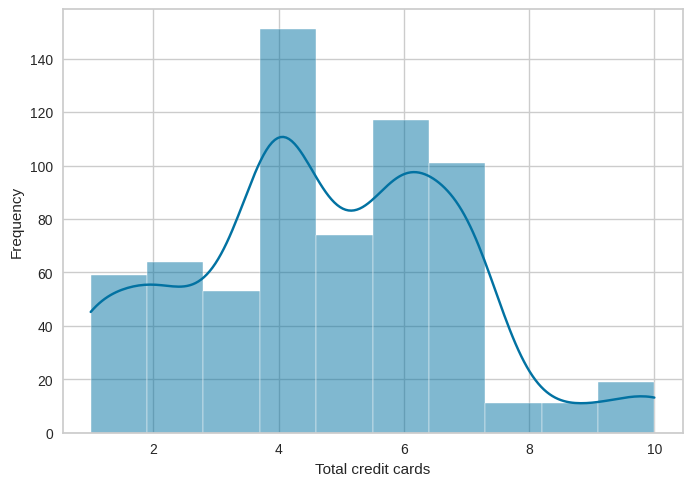

In [18]:
sns.histplot(df["Total_Credit_Cards"], bins=10, kde=True)
plt.xlabel("Total credit cards")
plt.ylabel("Frequency")
plt.show()



*   This data of total credit cards looks slightly normally distributed.



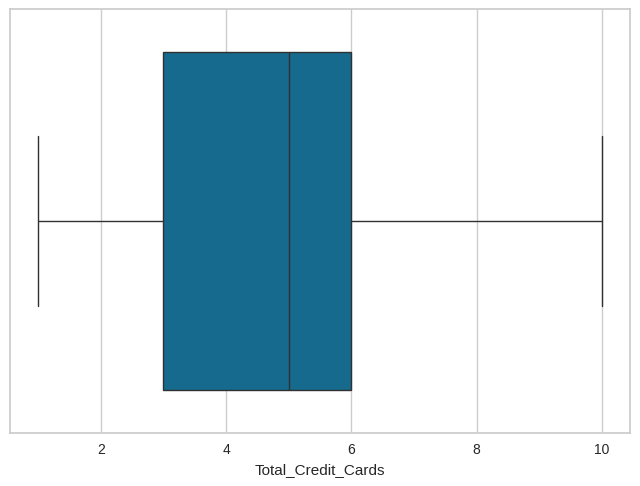

In [19]:
sns.boxplot(df,x="Total_Credit_Cards")
plt.show()



*   This data of total credit cards does not have outliers.



**Total bank visits**

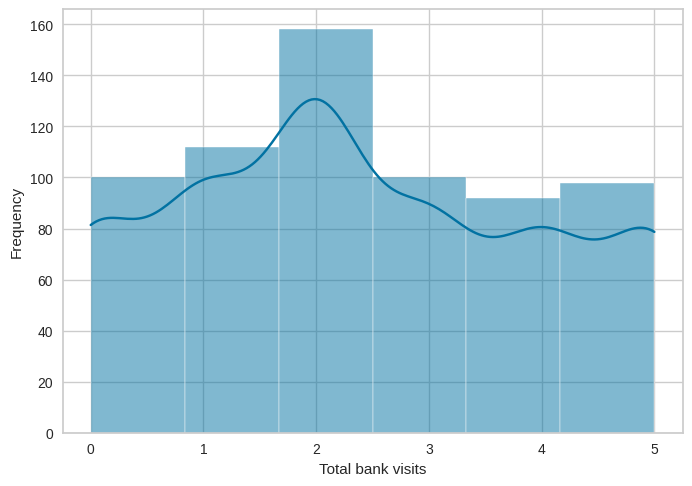

In [20]:
sns.histplot(df["Total_visits_bank"], bins=6, kde=True)
plt.xlabel("Total bank visits")
plt.ylabel("Frequency")
plt.show()



*   The data of total bank visits are normally distributed.



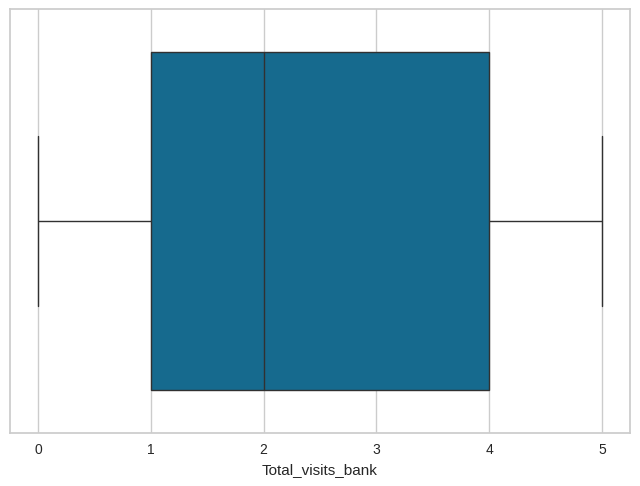

In [21]:
sns.boxplot(df,x="Total_visits_bank")
plt.show()

*   This data of total credit cards does not have outliers.

**Total Online Visits**

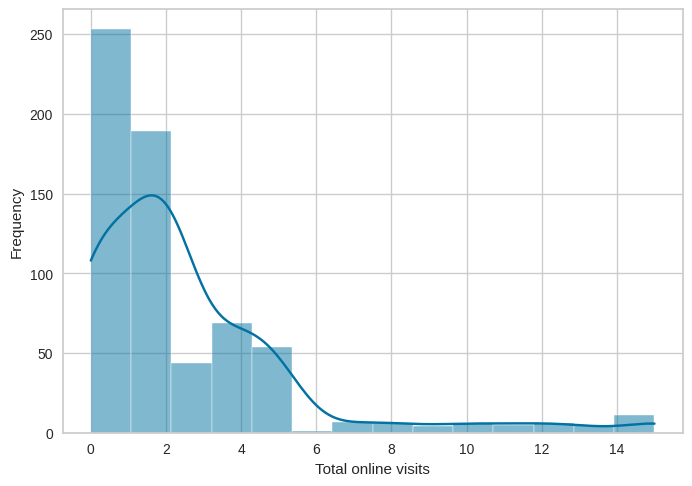

In [22]:
sns.histplot(df["Total_visits_online"], bins=14, kde=True)
plt.xlabel("Total online visits")
plt.ylabel("Frequency")
plt.show()



*   Most of the customers do not frequently visit online.



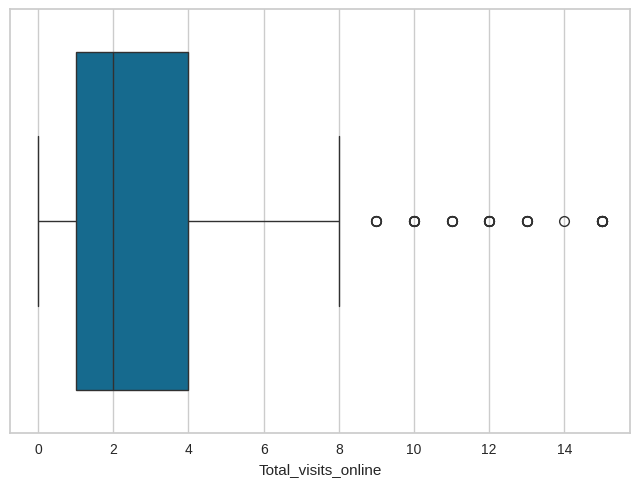

In [23]:
sns.boxplot(df,x="Total_visits_online")
plt.show()

*   The distribution is positively skewed.

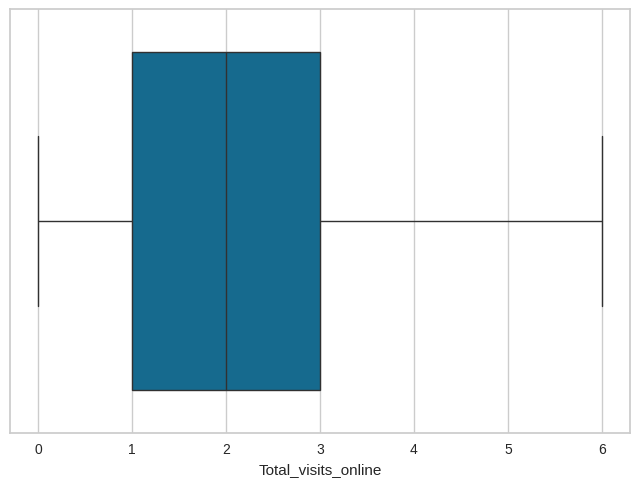

In [24]:
Q1 = data['Total_visits_online'].quantile(0.25)
Q3 = data['Total_visits_online'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data = data[(data['Total_visits_online'] >= lower_bound) & (data['Total_visits_online'] <= upper_bound)]
sns.boxplot(data,x='Total_visits_online')
plt.show()

**Total Calls Made**

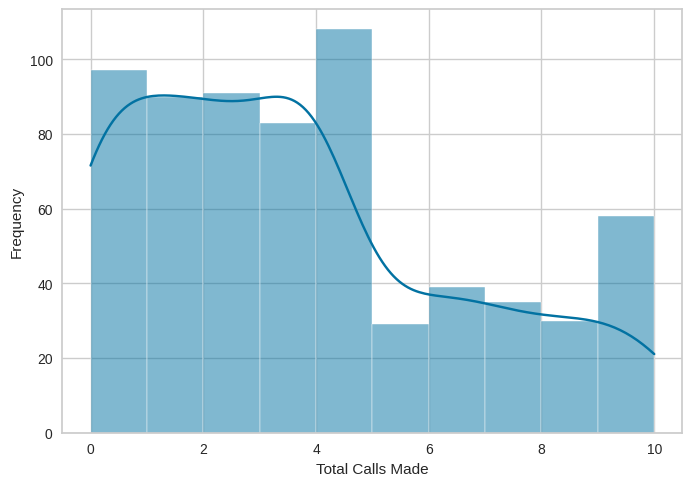

In [25]:
sns.histplot(df["Total_calls_made"], bins=10, kde=True)
plt.xlabel("Total Calls Made")
plt.ylabel("Frequency")
plt.show()



*   Most of the customers calls bank 0-5 times yearly.

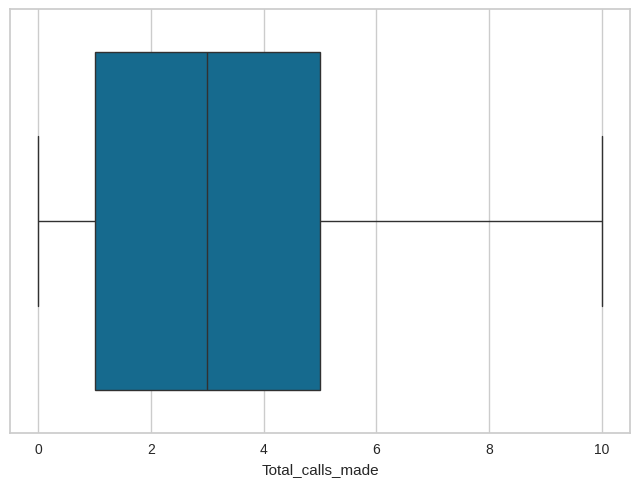

In [26]:
sns.boxplot(df,x="Total_calls_made")
plt.show()



*   The data of total calls made does not have outliers.

**Bivariate Analysis**

**Heat Maps**

In [27]:
Num_Col = ["Avg_Credit_Limit", "Total_Credit_Cards", "Total_visits_bank", "Total_visits_online", "Total_calls_made"]

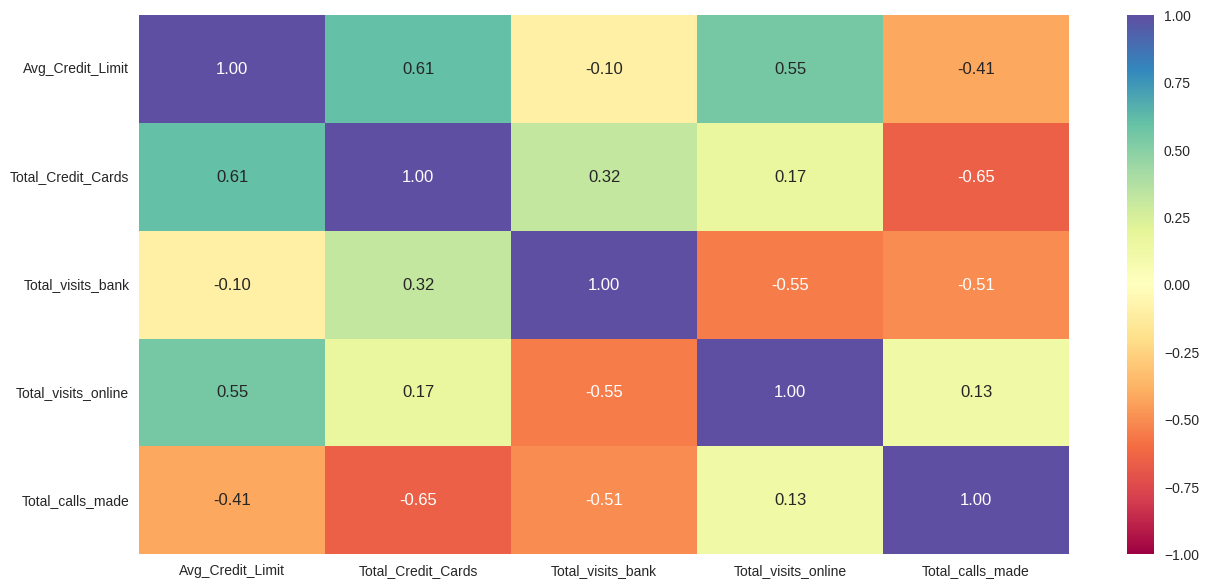

In [28]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[Num_Col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()



*   Total credit cards and Average credit card limits are positively corelated.

*   Total bank visit, total online visit and total calls made are negatively corelated which is quite obvious.

**Scatter Plot**

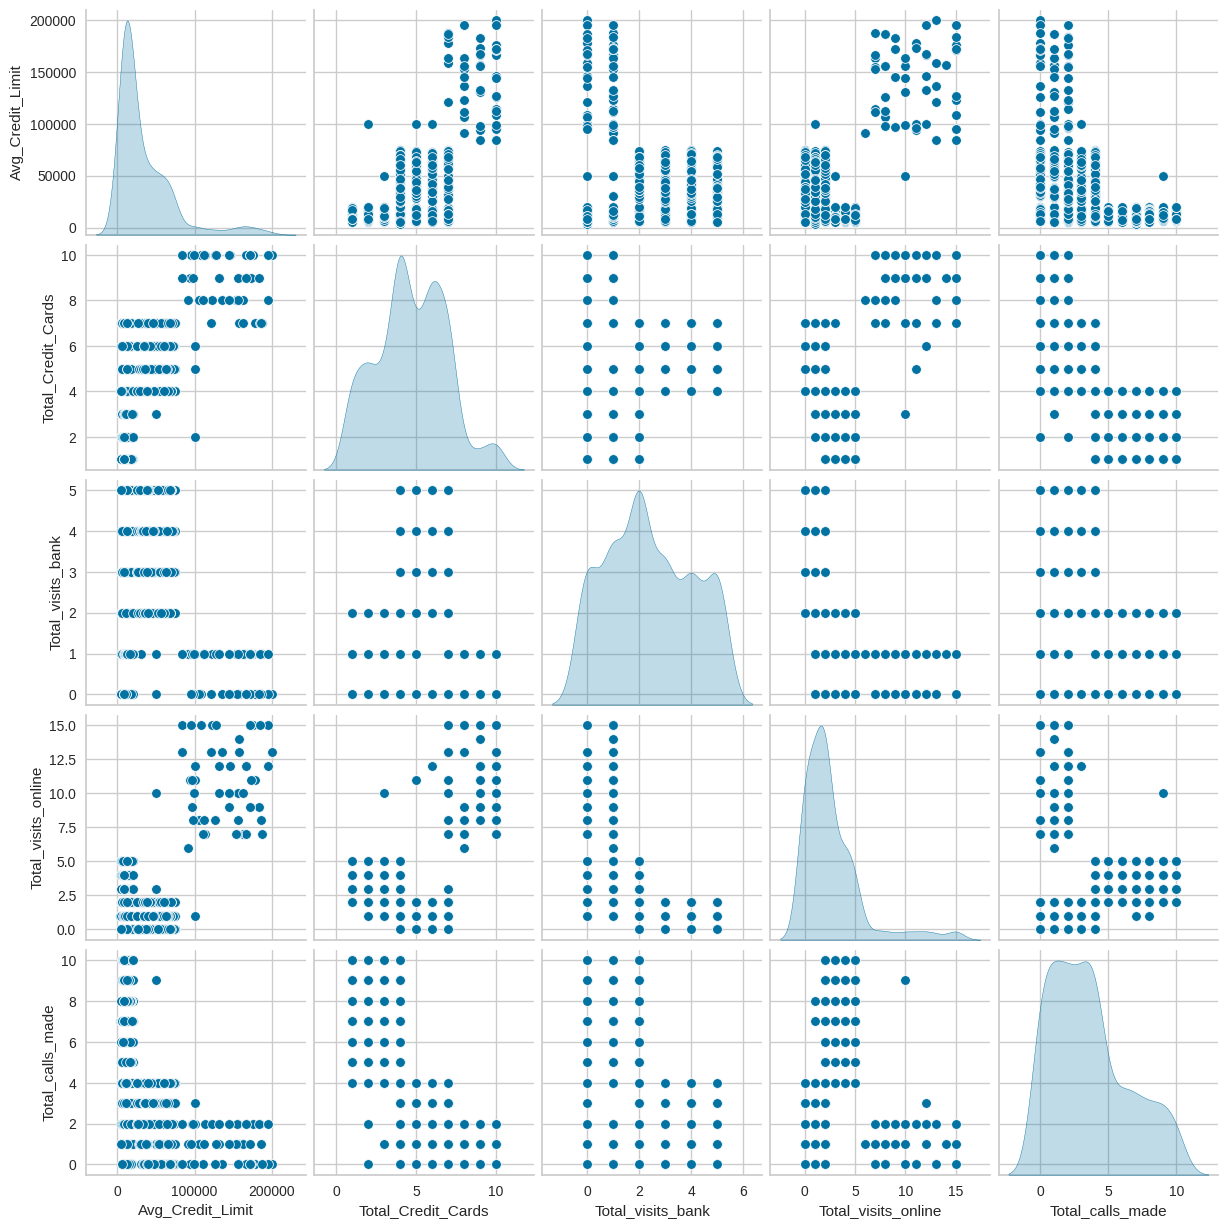

In [29]:
sns.pairplot(df[Num_Col], diag_kind="kde")
plt.show()

# **Data Preprocessing**

In [30]:
# variables used for clustering
Num_Col

['Avg_Credit_Limit',
 'Total_Credit_Cards',
 'Total_visits_bank',
 'Total_visits_online',
 'Total_calls_made']

In [31]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[Num_Col].copy()
subset_scaled = scaler.fit_transform(subset)
# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

In [61]:
subset_scaled_df

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,K_means_segments
0,1.740187,-1.249225,-0.860451,-0.547490,-1.251537,0
1,0.410293,-0.787585,-1.473731,2.520519,1.891859,1
2,0.410293,1.058973,-0.860451,0.134290,0.145528,0
3,-0.121665,0.135694,-0.860451,-0.547490,0.145528,0
4,1.740187,0.597334,-1.473731,3.202298,-0.203739,2
...,...,...,...,...,...,...
655,1.713589,2.443892,-0.860451,2.520519,-1.251537,2
656,1.314621,2.443892,-0.860451,3.543188,-0.553005,2
657,2.937092,1.520613,-0.860451,2.179629,-0.902271,2
658,3.655235,2.443892,-0.860451,4.224968,-1.251537,2


# **K-Mean Clustering**

Number of Clusters: 1 	Average Distortion: 2.006922226250361
Number of Clusters: 2 	Average Distortion: 1.7178787250175898
Number of Clusters: 3 	Average Distortion: 1.1466276549150365
Number of Clusters: 4 	Average Distortion: 1.0902973540817666
Number of Clusters: 5 	Average Distortion: 0.9906853650098948
Number of Clusters: 6 	Average Distortion: 0.9515009282361341
Number of Clusters: 7 	Average Distortion: 0.9094119827472316
Number of Clusters: 8 	Average Distortion: 0.9191292344244387


Text(0.5, 1.0, 'Selecting k with the Elbow Method')

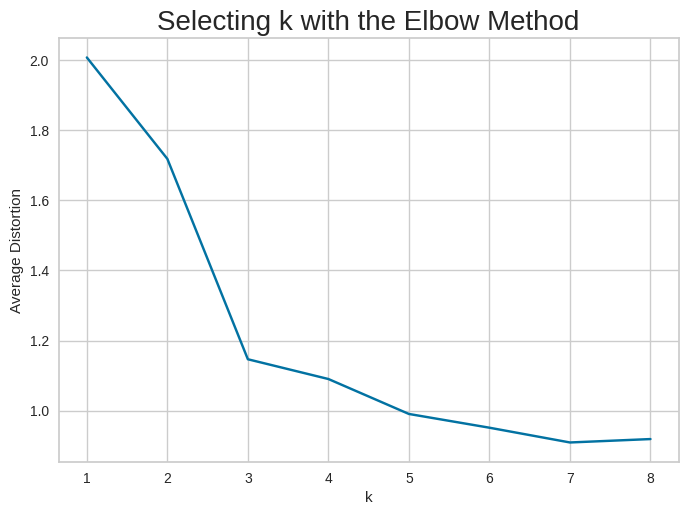

In [32]:
clusters = range(1, 9)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state = 1)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)



*   The appropriate value of k from the elbow curve seems to be 3 or 5.



# **Let's check the silhouette scores**

For n_clusters = 2, silhouette score is 0.5703183487340514
For n_clusters = 3, silhouette score is 0.5157182558881063
For n_clusters = 4, silhouette score is 0.3744071798973986
For n_clusters = 5, silhouette score is 0.27167502160723267
For n_clusters = 6, silhouette score is 0.24804756291576194
For n_clusters = 7, silhouette score is 0.24791254258020035
For n_clusters = 8, silhouette score is 0.22570382558070443
For n_clusters = 9, silhouette score is 0.19931783829027247


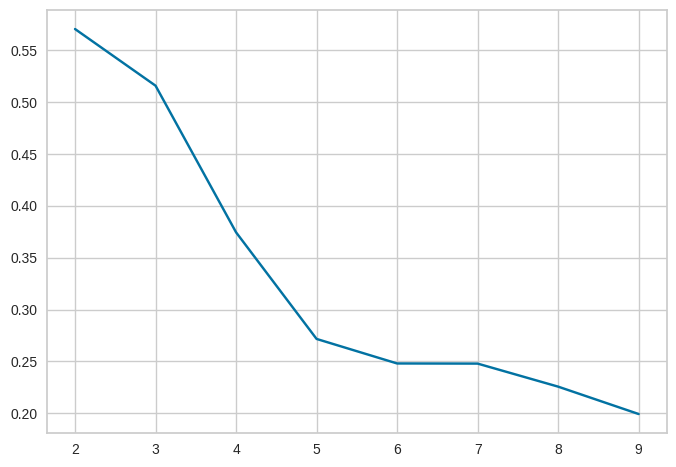

In [33]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state = 1)
    preds = clusterer.fit_predict((subset_scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

plt.plot(cluster_list, sil_score)



*   From the silhouette scores, it seems that 3 is a good value of k.



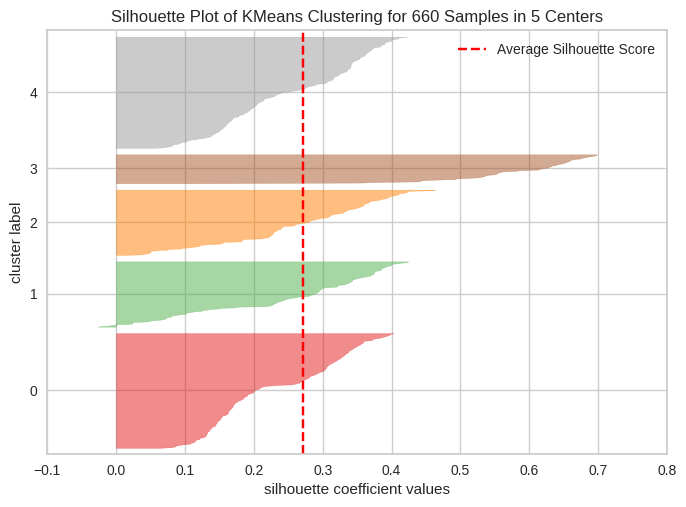

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [34]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

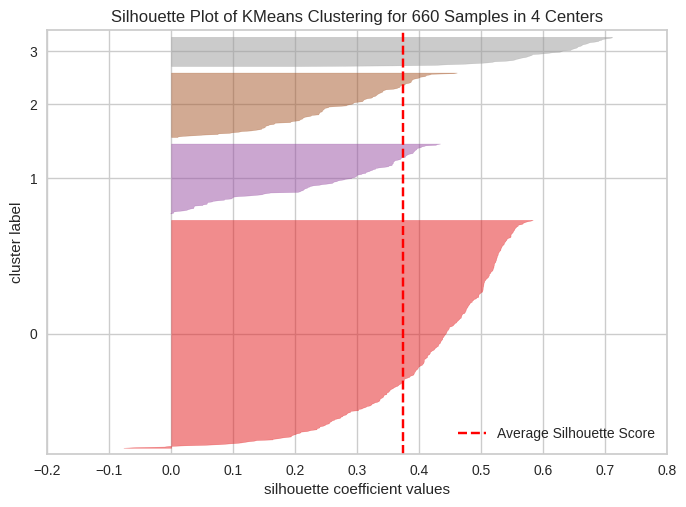

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [35]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

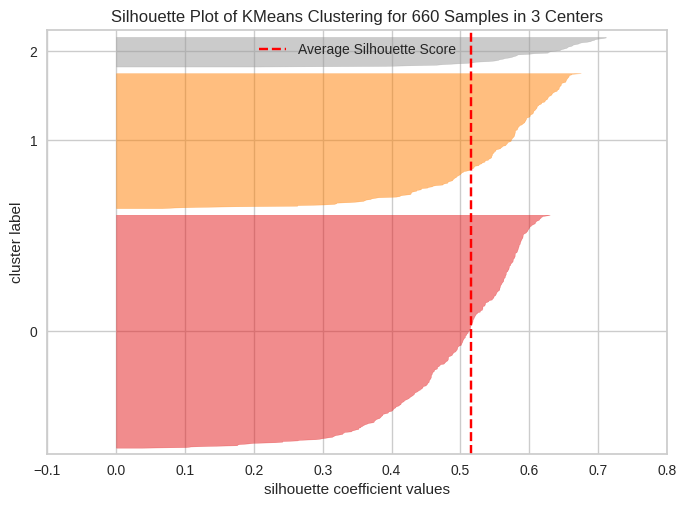

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [36]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

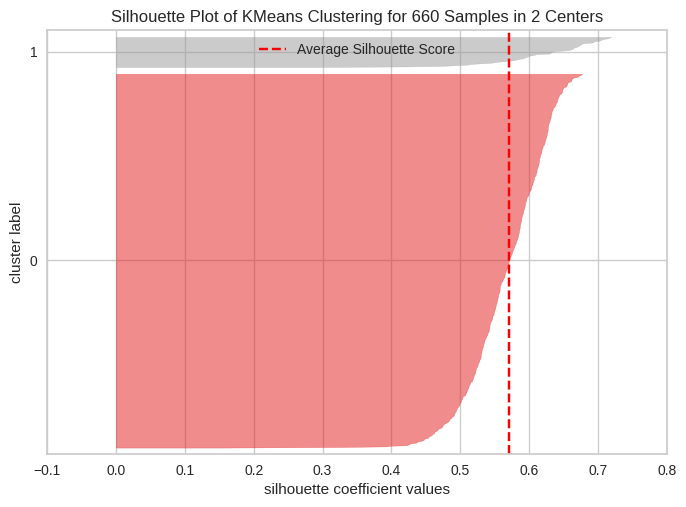

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [37]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()



*   We will proceed with K=3.



In [38]:
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=3, random_state=1)

In [39]:
# adding kmeans cluster labels to the original and scaled dataframes

df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

# **Cluster Profiling - K-Means Clustering**


In [40]:
cluster_profile = df.groupby("K_means_segments").mean(numeric_only = True)

In [41]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments").size().values
)

In [42]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,credit_limit_log,count_in_each_segments
K_means_segments,,,,,,,
0,33782.383420,5.515544,3.489637,0.981865,2.000000,10.152632,386
1,12174.107143,2.410714,0.933036,3.553571,6.870536,9.318248,224
2,141040.000000,8.740000,0.600000,10.900000,1.080000,11.825521,50


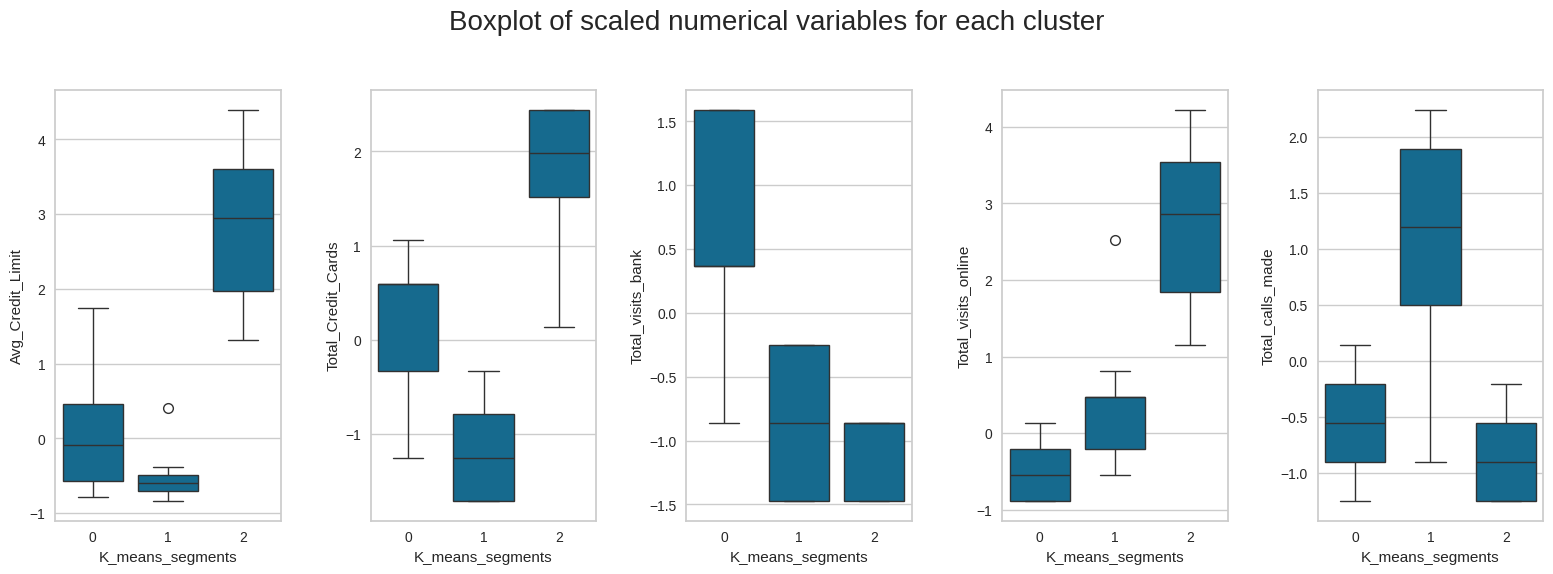

In [43]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[Num_Col[counter]],
        x=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

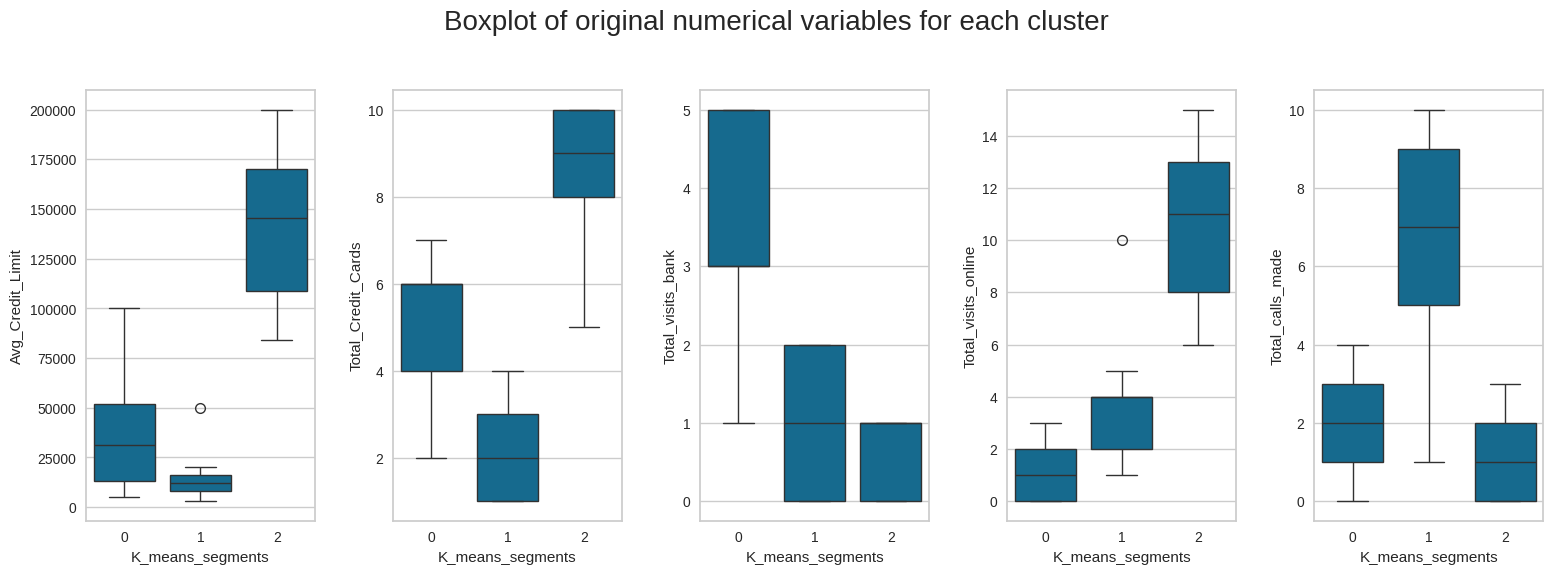

In [44]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[Num_Col[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

# **Insights**



*   **Cluster 0 —**

                  1. This cluster contains customers having medium average credit limit.
                  2. These customers has moderate number of credit cards (≈4–6).
                  3. These customers visits bank branch more oftenly.
                  4. These customers less likely to visit online.
                  5. These cluster has customers having low–moderate call volume.
*   **Cluster 1 —**
                  
                  1. This cluster contains customers having low credit limit.
                  2. These customers has fewer credit cards (≈1–3).
                  3. These customers less likely to visit branch.
                  4. These customers has moderate online visits.
                  5. These cluster has customers having highest call volume.


*   **Cluster 2 —**

                  1. This cluster contains customers having highest credit limit.
                  2. These customers has most credit cards (≈8–10).
                  3. These customers has very low branch visits.
                  4. These customers has highest online visits.
                  5. These cluster has low call volume.


# **Hierarchical Clustering**

**Computing Cophenetic Correlation**

In [45]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.8788676940541079.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8860521900934342.
Cophenetic correlation for Euclidean distance and average linkage is 0.9168725782090766.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.9133393931042242.
Cophenetic correlation for Chebyshev distance and single linkage is 0.8978014062578786.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8623270916886306.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9160784250471772.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9109044268579872.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.8959952526724227.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6550023123197851.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8467618899578889.
Cophenetic co

In [46]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9168725782090766, which is obtained with Euclidean distance and average linkage.


# **Checking Dendrograms**

We see that the cophenetic correlation is maximum with Euclidean distance and average linkage.

Let's view the dendrograms for the different linkage methods.

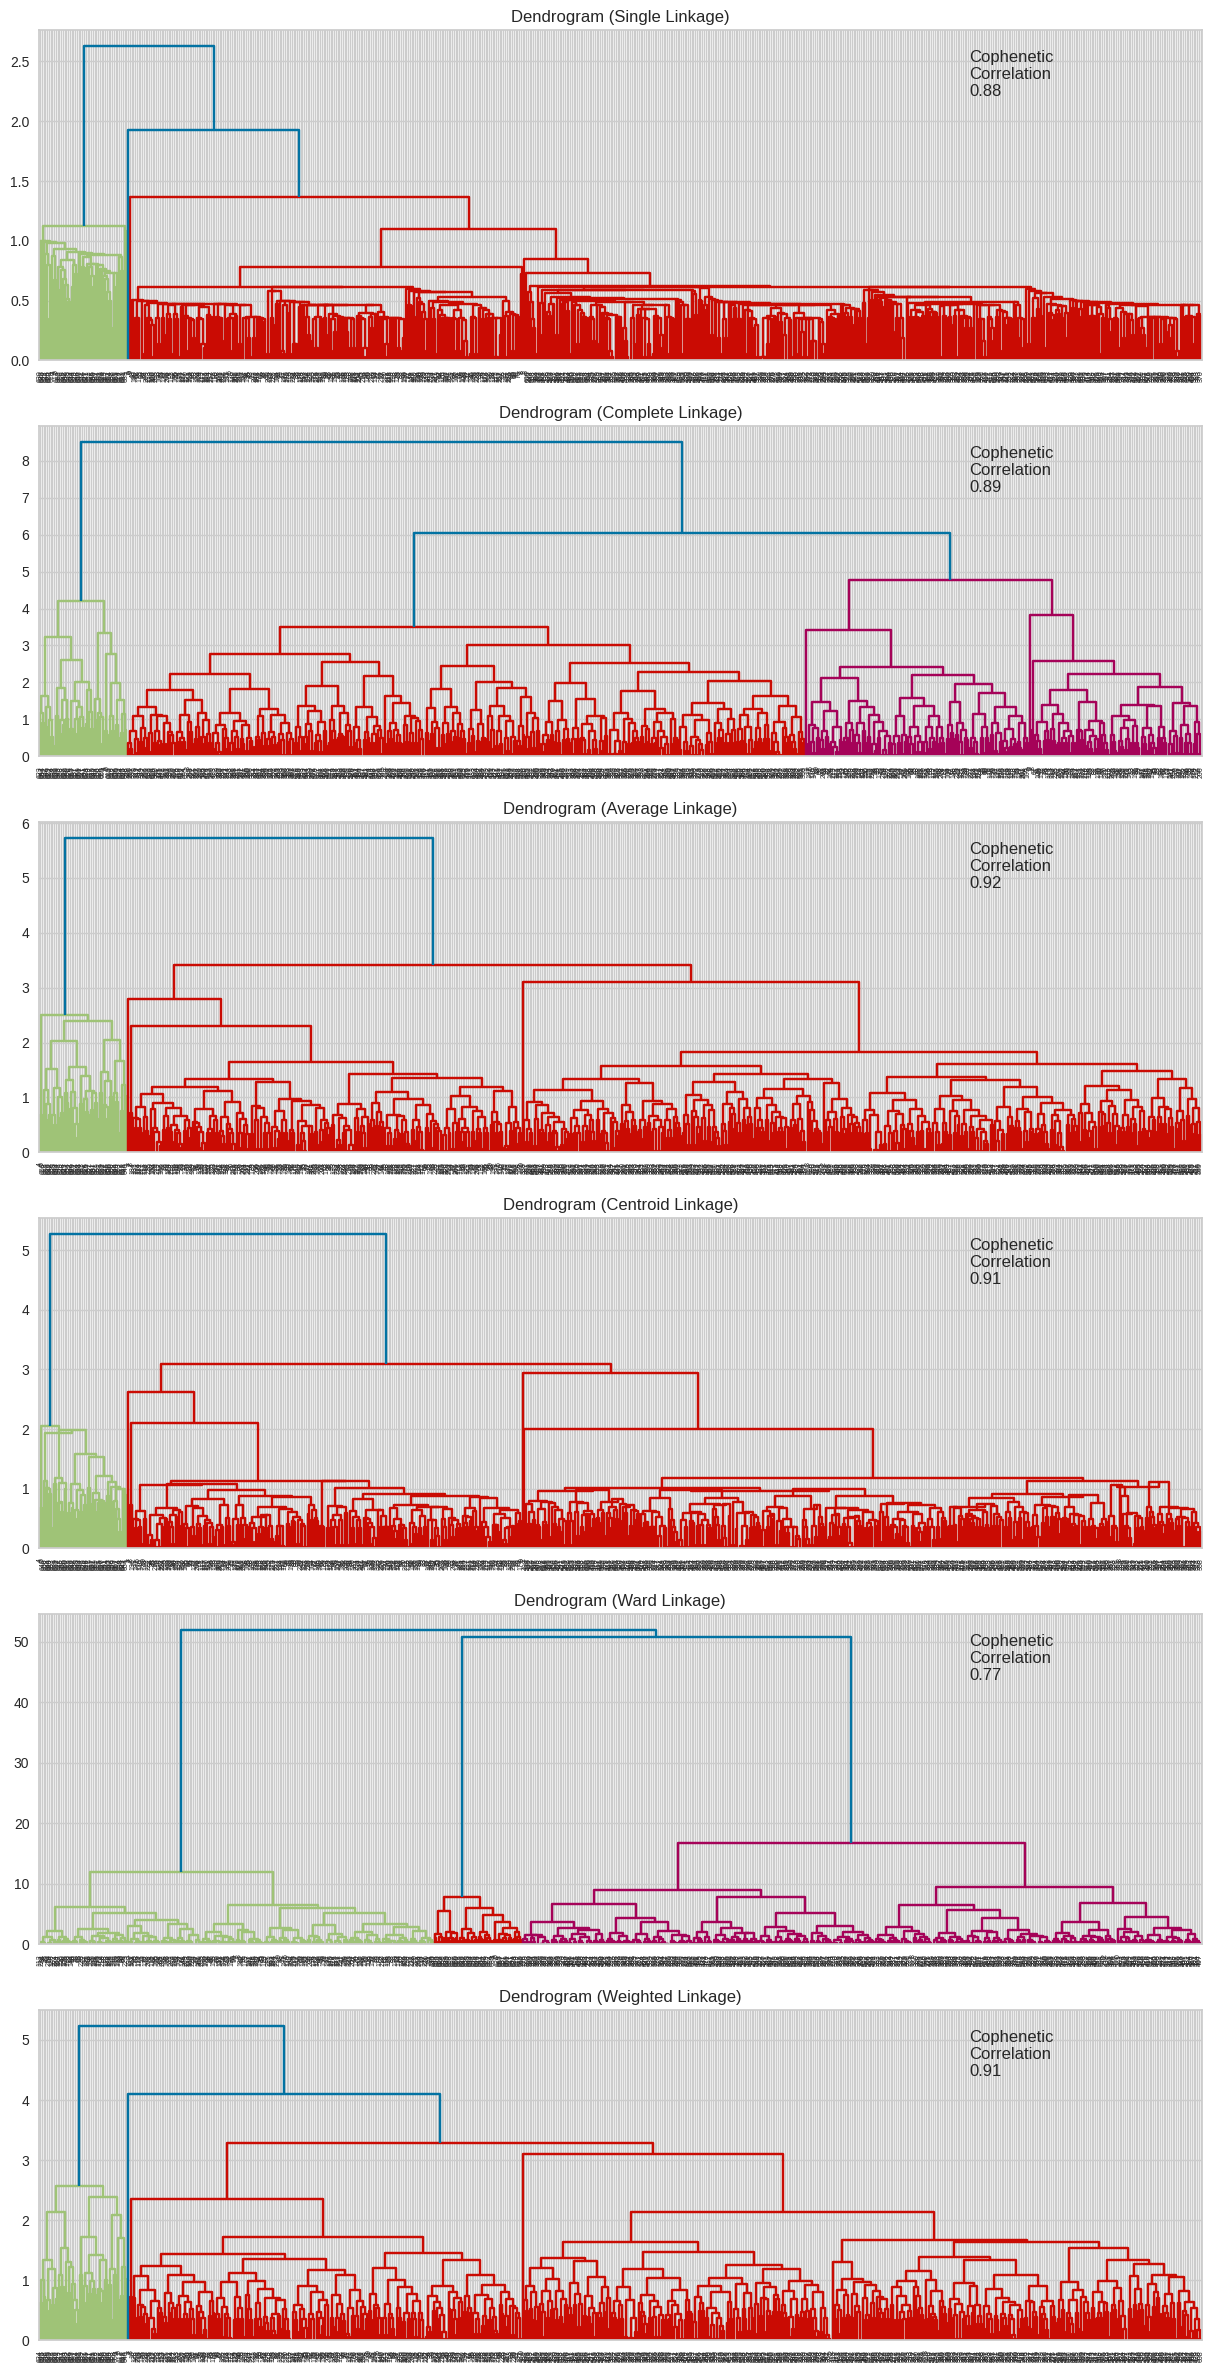

In [47]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

**Observations**
1. From above dendograms, the average linkage seems clear hierarchy with meaningful separation.
2. So, 3 will be good choice of number of clusters.

# **Creating Final Model**

In [48]:
hc = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
hc_labels = hc.fit_predict(subset_scaled_df)

In [49]:
hc_df = pd.DataFrame(
    subset_scaled_df,
    columns=[f"feature_{i}" for i in range(subset_scaled_df.shape[1])]
)

hc_df["HC_segments"] = hc_labels

# **Cluster Profiling-Hierarchical Clustering**

In [50]:
hc_df.groupby("HC_segments").mean()
hc_df["HC_segments"].value_counts()

,count
HC_segments,
0,386
2,224
1,50


In [51]:
Num_Col = [
    "Avg_Credit_Limit",
    "Total_Credit_Cards",
    "Total_visits_bank",
    "Total_visits_online",
    "Total_calls_made"
]
hc_df = subset_scaled_df[Num_Col].copy()
hc_df["HC_segments"] = hc_labels


In [52]:
hc_df_profiling = hc_df.groupby("HC_segments")[Num_Col].mean()
hc_df_profiling["count_in_each_segment"] = (
    hc_df.groupby("HC_segments").size().values
)

# displaying the group-wise means of variables
hc_df_profiling.style.highlight_max(color="lightgreen", axis=0)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segment
HC_segments,,,,,,
0,-0.021062,0.373690,0.666395,-0.553672,-0.553005,386
1,2.831764,1.862226,-1.105763,2.827319,-0.874330,50
2,-0.595796,-1.059623,-0.901518,0.322997,1.148109,224


In [53]:
# let's plot the attributes of clusters
c1 = [0, 1, 2]
hc_df2 = hc_df[hc_df.HC_segments.isin(c1)]
hc_df2 = hc_df2.reset_index()


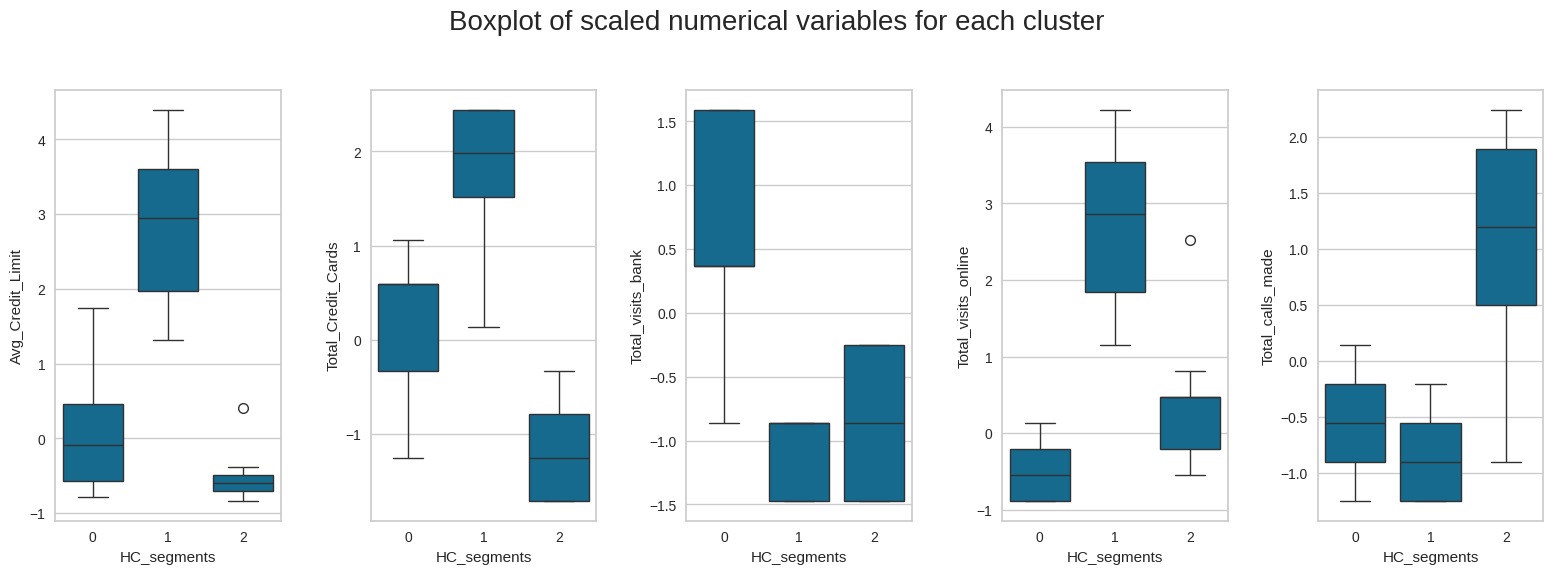

In [54]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)

for i, col in enumerate(Num_Col[:5]):  # first 5 columns
    sns.boxplot(
        ax=axes[i],
        y=hc_df2[col],
        x=hc_df2["HC_segments"],
    )

fig.tight_layout(pad=2.0)

# **Insights**



*   **Cluster 0-**

                  1. This cluster contains customers having medium average credit limit.
                  2. These customers has moderate number of credit cards.
                  3. These customers visit branch frequently.
                  4. These customes less likely to visit online.
                  5. These customers calls fewer times.
*   **Cluster 1-**

                  1. This cluster contains customers having high average credit limit.
                  2. These customers has slightly higher number of cards than average.
                  3. These customers rarely visits bank physically.
                  4. This cluster has very active online users.
                  5. This cluster shows low calling activity.
*   **Cluster 2-**

                  1. This cluster contains customers having low average credit limit.
                  2. These customers has fewer credit cards.
                  3. These customers has average physical bank activity.
                  4. This cluster has moderate online engagement.
                  5. This cluster actively calls the bank.


# **PCA for Visualization**

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced_pca = pca.fit_transform(hc_df2)

# storing results in a dataframe
reduced_data_df_pca = pd.DataFrame(
    data=X_reduced_pca, columns=["Component 1", "Component 2"]
)

# checking the amount of variance explained
print(
    f"The first two principal components explain {np.round(100*pca.explained_variance_ratio_.sum(), 2)}% of the variance in the data."
)

The first two principal components explain 100.0% of the variance in the data.


<Axes: xlabel='Component 1', ylabel='Component 2'>

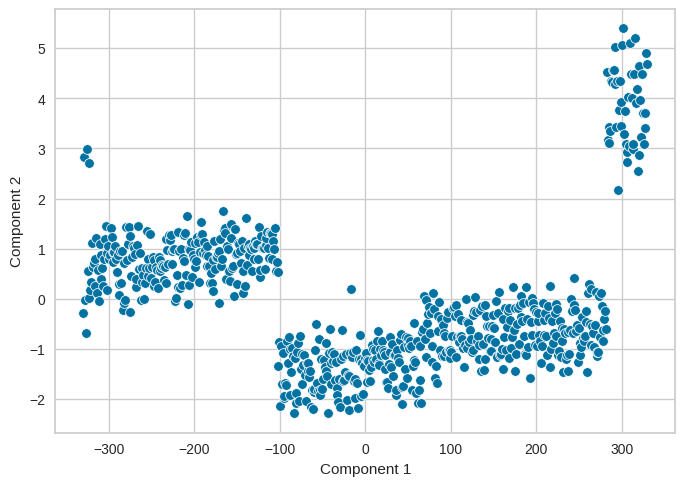

In [56]:
sns.scatterplot(data=reduced_data_df_pca, x="Component 1", y="Component 2")

<Axes: xlabel='Component 1', ylabel='Component 2'>

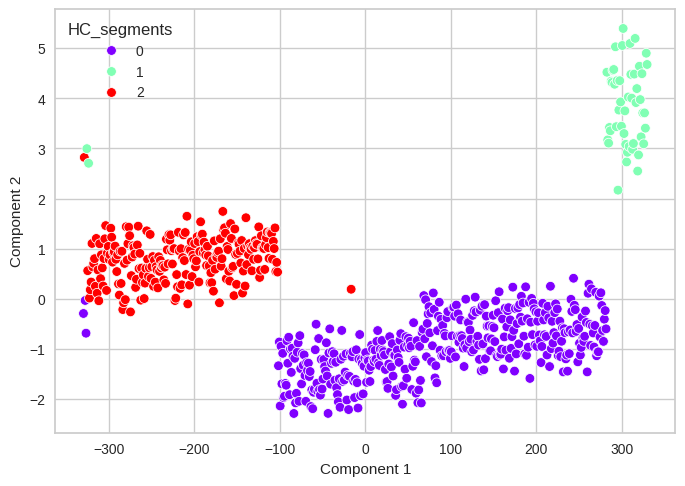

In [57]:
sns.scatterplot(
    data=reduced_data_df_pca,
    x="Component 1",
    y="Component 2",
    hue=hc_df["HC_segments"],
    palette="rainbow",
)



*   Clusters are well separated.

# **Recommendations**
**Hierarchical Clustering**

**Cluster 0-**

 **Branch-to-Digital Migration**

Train branch staff to actively onboard customers to mobile/online banking during visits.


**Incentivize Online Usage**

Provide fee waivers, reward points, or cashback for first few online transactions.

Run campaigns like “Go Digital & Save Time”.

**Simple Credit Growth Offers**

Offer small, pre-approved credit limit increases or entry-level card upgrades.

Use branch interactions to explain benefits clearly.

**Cluster 1-**

**Premium & Personalized Offers**

Promote premium cards, higher credit limits, wealth products, and loans.

Use AI-driven personalization in app/email campaigns.

**Digital-First Engagement**

Offer exclusive app-only benefits, faster approvals, concierge chat support.

Introduce self-service advanced tools (spend analytics, credit insights).

**Loyalty & Retention Programs**

Tier-based rewards, airport lounge access, lifestyle partnerships.

Early access to new features or products.

**Cluster 2-**

**Call Reason Analysis**

Identify top call drivers (billing issues, card usage confusion, disputes).

Fix root causes through clearer communication or app improvements.

**Guided Self-Service**

Introduce in-app FAQs, chatbots, and step-by-step guides for common issues.

Send post-call follow-ups showing how to self-resolve next time.

**Targeted Product Education**

Educate on existing card benefits, EMI options, and spending controls.

Upsell an additional card once confidence improves.


